Loaded shape: (101, 128, 128, 2)


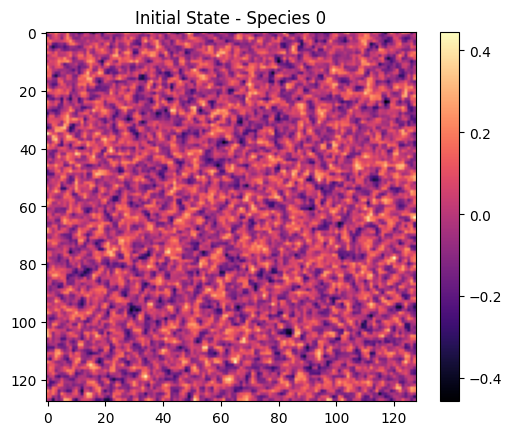

In [ ]:
import h5py
import os
#load hdf5 file
import pickle
import numpy as np
import matplotlib.pyplot as plt

file = "2D_diff-react_NA_NA.h5"

with h5py.File(file, 'r') as f:
    all_keys = list(f.keys())
    
    # 2. Randomly choose 102 keys without replacement
    random_keys = np.random.choice(all_keys, size=102, replace=False)
    sampled_data_list = [f[key]['data'][:] for key in random_keys]
    final_samples = np.stack(sampled_data_list)
    
    # Access the 'data' dataset inside the '0000' group
    full_data = f['0000']['data'][:] 
print(f"Loaded shape: {full_data.shape}")

# Example: Plot the first time step, first species
# [time_index, x, y, species_index]
plt.imshow(full_data[ 1, :, :, 0], cmap='magma')
plt.title("Initial State - Species 0")
plt.colorbar()
plt.show()


In [48]:
final_samples[0][0]

array([[[-1.228394  , -0.8724471 ],
        [-0.49276638, -1.3915849 ],
        [ 1.5182363 , -0.05422026],
        ...,
        [-1.4341205 , -0.48825392],
        [ 0.5234718 ,  1.6480737 ],
        [-0.22996095,  0.7284689 ]],

       [[-0.9725919 , -0.14722465],
        [-1.0968218 , -1.4469473 ],
        [ 0.8362378 ,  0.07885624],
        ...,
        [-1.6413133 ,  0.05801573],
        [ 0.1166924 ,  0.2748847 ],
        [ 1.3885969 ,  0.21029952]],

       [[-0.51762074, -0.8078965 ],
        [ 0.7613227 ,  1.4454299 ],
        [-1.8841933 ,  1.0043837 ],
        ...,
        [-0.5477165 , -0.6926591 ],
        [ 0.71931505,  1.4549328 ],
        [-0.9547478 , -1.6107944 ]],

       ...,

       [[ 0.8767756 , -0.679502  ],
        [-1.4475766 , -0.06461029],
        [ 0.16672738, -0.25212407],
        ...,
        [-1.470103  , -0.39809877],
        [ 1.4062195 , -1.6656578 ],
        [ 0.16875347,  1.3241407 ]],

       [[ 1.7068819 , -0.25146163],
        [ 0.63733244, -1.02

In [19]:
full_data.shape

(101, 128, 128, 2)

In [4]:
parameter_values = {'a': 1, 'nu': 0.1, 'p': 0.1}
paras = {'nu': 0.1, 'p': 0.1}

formatted_str = "\n".join([
    f"    const float {k} = {v};" if k not in paras else f"    const float {k} = {{{{{k}}}}};"
    for k, v in parameter_values.items()
])

print(formatted_str)

    const float a = 1;
    const float nu = {{nu}};
    const float p = {{p}};


In [65]:
# 1. Prepare channels
r_channel = np.tile(random_samples[0][0], (len(xcoor), 1))
g_channel = np.zeros_like(r_channel)
b_channel = np.zeros_like(r_channel)
a_channel = np.full_like(r_channel, 255)

# 2. Interleave and FLATTEN to 1D
# We use .ravel() to turn the 2D grid into one long sequence to match the JS loop
rgba_flat = np.dstack([r_channel, g_channel, b_channel, a_channel]).ravel()

# 3. Save as a single line
with open('random_sample_t0.csv', 'w') as f:
    # Header: width,height, (matching the JS comma logic)
    f.write(f"{random_samples.shape[2]},{random_samples.shape[2]},")
    
    # Save the flattened array as a single row
    # Using reshape(1, -1) forces savetxt to treat it as one line
    np.savetxt(f, rgba_flat.reshape(1, -1), delimiter=",", fmt="%.18e")


r_channel = np.tile(random_samples[0][-1], (len(xcoor), 1))

g_channel = np.zeros_like(r_channel)
b_channel = np.zeros_like(r_channel)
a_channel = np.zeros_like(r_channel)

rgba_interleaved = np.dstack([r_channel, g_channel, b_channel, a_channel]).reshape(len(xcoor), -1)

with open('random_sample_t-1.csv', 'w') as f:
    f.write(f"{random_samples.shape[2]},{random_samples.shape[2]},")
    np.savetxt(f, rgba_interleaved, delimiter=",")

In [82]:
def reverse_csv_to_sample(file_path):
    # 1. Load the data, skipping the first two header values
    # We use 'flatten' because the first line contains the header
    raw_data = np.genfromtxt(file_path, delimiter=",")
    
    # 2. Separate the header from the pixel data
    # The first two elements are random_samples.shape[2]
    header = raw_data[:2]
    pixel_data = raw_data[2:]
    
    # 3. Reshape back to (Length, 4) to separate R, G, B, and A
    # The length is determined by the number of coordinates (xcoor)
    rgba_matrix = pixel_data.reshape(-1, 4)
    
    # 4. Extract the Red channel (column 0)
    # Since the original was tiled, every row in the Red channel is identical
    r_channel_full = rgba_matrix[:, 0]
    
    # 5. Get the original 1D array
    # We know the original length from the header we saved (shape[2])
    original_length = int(header[0])
    recovered_sample = r_channel_full[:original_length]
    
    return recovered_sample
def calculate_nrmse(actual, predicted):
    # 1. Calculate RMSE
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    
    # 2. Calculate the range of the actual data for normalization
    # (This is the most common normalization method)
    data_range = np.max(actual) - np.min(actual)
    
    # 3. Handle potential division by zero if all values in 'actual' are the same
    if data_range == 0:
        return rmse / np.mean(actual) if np.mean(actual) != 0 else rmse
        
    return rmse / data_range
result = reverse_csv_to_sample('../../simulation_downloads/result.csv')


In [83]:
nrmse_value = calculate_nrmse(random_samples[0][-1], result)
print(f"NRMSE between original and recovered sample: {nrmse_value}")

NRMSE between original and recovered sample: 0.004823542335171014


In [79]:
result

array([0.13883108, 0.14769609, 0.15660921, ..., 0.11253236, 0.12124847,
       0.13001496], shape=(1024,))

In [71]:
random_samples[0][-1]

array([0.13605607, 0.14500147, 0.15399636, ..., 0.10952438, 0.11831681,
       0.12716092], shape=(1024,), dtype=float32)

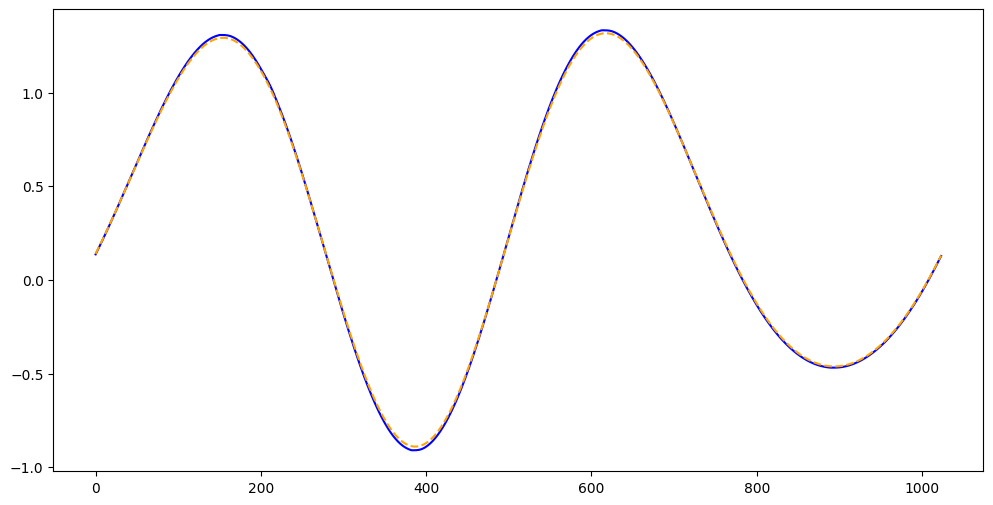

: 

In [ ]:
# plot result and random_samples[0][-1]
plt.figure(figsize=(12, 6))
plt.plot(random_samples[0][-1], label='Original Sample (t=-1)', color='blue')
plt.plot(result, label='Recovered Sample from CSV', color='orange', linestyle='--')